# Notebook 05 -- Training OCR (CRNN + CTC) — REVISED v4
**Spendly AI -- Coding Camp 2026 powered by DBS Foundation (CC26-PSU276)**

**Revisi v4 dari v3:**
- Text bank diperluas: targeted hard-case patterns (quantity, invoice, lowercase, price, total, payment)
- Distribusi dataset 40K: 50% normal, 25% hard-targeted, 15% numeric-heavy, 10% real crop
- Source tracking per sample untuk debugging
- Augmentasi tambahan: gaussian blur + horizontal stretch
- Arsitektur: SpatialDropout2D + recurrent_dropout di BiLSTM
- ReduceLROnPlateau di training loop
- Early stopping patience diperketat: 15 epoch
- Sanity check 200 preview sebelum full generation


In [1]:
import os, sys, time, string
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, mixed_precision
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass
import editdistance
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import json

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'Memory growth aktif: {gpus}')
    except RuntimeError:
        pass

# Float32 sejak awal — mixed_float16 menyebabkan weights corrupt saat di-save/load
mixed_precision.set_global_policy('float32')
print(f'Mixed precision policy: {mixed_precision.global_policy().name}')  # harus: float32

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
from custom_components import CTCLayer

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f'TF: {tf.__version__}')


Memory growth aktif: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: float32
TF: 2.10.0


In [2]:
import subprocess

gpus = tf.config.list_physical_devices('GPU')
print(f"Jumlah GPU terdeteksi TF: {len(gpus)}")
for gpu in gpus:
    print(f"  Device: {gpu.name}")

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print("\nnvidia-smi GPU info:")
    for line in result.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"nvidia-smi tidak tersedia: {e}")

print(f"\nGPU aktif untuk TF: {tf.test.gpu_device_name()}")


Jumlah GPU terdeteksi TF: 1
  Device: /physical_device:GPU:0

nvidia-smi GPU info:
  0, NVIDIA GeForce RTX 3060 Ti, 8192 MiB, 6977 MiB

GPU aktif untuk TF: /device:GPU:0


In [3]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Enable mixed precision for better GPU memory usage
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f'Mixed precision policy: {policy.name}')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6
Mixed precision policy: mixed_float16


## 5.1 -- Konstanta & Text Bank (v4: Diperluas dengan Targeted Hard-Case Patterns)

In [4]:
IMG_W, IMG_H = 400, 50
MAX_LABEL_LEN = 40

CHARS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz .,:-/()%"
CHAR_TO_IDX = {c: i + 1 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {i + 1: c for i, c in enumerate(CHARS)}

BLANK_IDX = len(CHARS) + 1  # 72
NUM_CHARS  = len(CHARS) + 2  # 73

print(f'CHARS    : {len(CHARS)} karakter')
print(f'BLANK_IDX: {BLANK_IDX}')
print(f'NUM_CHARS: {NUM_CHARS}')
print(f'MAX_LABEL_LEN: {MAX_LABEL_LEN}')

# ─────────────────────────────────────────────────────────────────────────────
# RECEIPT TEXT BANK v3 — base bank (identik v2, tidak diubah)
# ─────────────────────────────────────────────────────────────────────────────
RECEIPT_TEXT_BANK = {
    "merchant_header": [
        "INDOMARET", "ALFAMART", "SUPERINDO", "GUARDIAN", "SOCIOLLA",
        "WATSONS", "ACE HARDWARE", "MR DIY", "SOLARIA", "STARBUCKS",
        "MCDONALDS", "BURGER KING", "FORE COFFEE", "KOPI KENANGAN",
        "SHELL", "PERTAMINA", "MINISO", "UNIQLO", "ALFAMIDI",
        "LAWSON", "FAMILY MART", "CIRCLE K", "HYPERMART",
        "LOTTEMART", "TRANSMART", "GIANT", "HERO SUPERMARKET",
    ],
    "address": [
        "Jl. Raya No. 12", "Jl. Sudirman 45", "Jl. Gatot Subroto",
        "Surabaya, Jawa Timur", "Jakarta Selatan 12190",
        "Jl. Pahlawan No. 7", "Jl. Ahmad Yani 100",
        "Jl. Pemuda No. 33", "Jl. Diponegoro 15",
    ],
    "item_name": [
        "ULTRA MILK 250ml", "MALKIST CRACKERS", "AQUA 600ml",
        "INDOMIE GORENG", "SABUN LIFEBUOY", "SHAMPO CLEAR 170ml",
        "PASTA GIGI PEPSODENT", "RINSO CAIR 1L", "SOKLIN SOFTENER",
        "MASKER WAJAH KF94", "VITAMIN C 1000mg", "POCARI SWEAT 500ml",
        "TARO NET SNACK", "OREO SANDWICH 137g", "CHITATO SAPI 68g",
        "KOPIKO CANDY", "GOOD DAY 3in1", "NESCAFE CLASSIC",
        "TEH BOTOL SOSRO", "SUSU SGM 400g", "MILO ACTIV GO 200ml",
    ],
    "price": [
        "Rp 15.000", "Rp 28.500", "Rp 45.000", "Rp 99.900",
        "Rp 125.000", "Rp 250.000", "Rp 1.250.000", "Rp 500",
        "15.000", "28.500", "99.900", "125.000",
    ],
    "total": [
        "TOTAL 88.000", "TOTAL: 88.000", "GRAND TOTAL 150.000",
        "Sub Total: 55.000", "TOTAL BAYAR: 200.000",
        "Total Tagihan: 175.000", "Tagihan: 99.000",
    ],
    "date_time": [
        "01/05/2026 14:32", "12-04-2026", "2026-05-01",
        "Tgl: 01/05/2026", "15/03/2026 09:15",
    ],
    "cashier": [
        "Kasir: Budi", "Kasir: Sari", "Kasir: 001",
        "Operator: Andi", "Served by: Dewi",
    ],
}

# ─────────────────────────────────────────────────────────────────────────────
# TARGETED TEXT BANK TAMBAHAN v4
# Fokus: pola yang CER tinggi dari quick check sebelumnya
# WARNING: ini SEASONING bukan main dish — proporsi dijaga di generator
# ─────────────────────────────────────────────────────────────────────────────
RECEIPT_TEXT_BANK_EXTRA = {
    "quantity_format": [
        "1x48", "2x120", "3x45", "4x82", "5x33",
        "6x61", "8x99", "10x25", "7x60", "12x15",
        "2x1.500", "3x2.750", "4x12.500", "6x8.000", "1x45.000",
        "Qty: 3", "Qty: 12", "Qty: 5 pcs",
        "2 pcs x 15.000", "3 lbr x 500", "1 btl x 28.500",
        "4 bks x 3.500", "6 klg x 12.000",
    ],
    "invoice_format": [
        "Invoice: INV-2026050", "Invoice: INV-20260501",
        "No: INV-001/2026", "Ref: TRX-20260512",
        "No Nota: 00123", "No Faktur: F-2026",
        "Struk: 0042691", "Ref: 20260501-001",
        "TRX ID: 8823761", "Order: ORD-20260430",
        "No: 2026/05/0012", "Bon: B-00451",
        "Nota: 20260512-007", "ID: TRX-88237",
    ],
    "lowercase_mixed": [
        "Kembali: 70.780", "Kembalian: 96.339",
        "Subtotal: 45.000", "Diskon: 5.000",
        "Total bayar: 120.000", "Tunai: 150.000",
        "Kembali: 30.000", "Pajak: 11.000",
        "Harga: 25.500", "Jumlah: 8.750",
        "Total item: 5", "Kasir: Budi",
        "Terima kasih", "Selamat berbelanja",
        "Pelanggan Yth.", "Member: Andi S.",
        "Tanggal: 01/05/2026", "Jam: 14:32:05",
        "Cabang: Surabaya", "Toko: Alfamart 012",
    ],
    "price_format": [
        "Rp105.800", "Rp1.923.190", "Rp 45.000",
        "Rp 1.250.000", "Rp12.500", "Rp 500",
        "Rp 99.900", "Rp 2.500.000", "Rp 175.000",
        "Total: Rp 88.000", "Bayar: Rp 200.000",
        "PPN 11%: 8.100", "PPN 810", "PPN 9 810",
        "Disc 10%: 5.000", "Disc: Rp 2.500",
        "Rp 37.500", "Rp 4.800", "Rp 13.200",
    ],
    "alphanumeric_code": [
        "BCA QRIS", "QRIS BNI", "GoPay QRIS",
        "OVO: 081234567890", "DANA: 08987654321",
        "ShopeePay OK", "LinkAja Tunai",
        "Mandiri Debit", "BNI Credit",
        "VISA ****1234", "MASTER ****5678",
        "EDC: 00123456", "Approval: A12345",
        "TID: 12345678", "MID: 987654321",
    ],
    "total_format": [
        "TOTAL BELANJA 2.737", "TOTAL: 88.000",
        "GRAND TOTAL 150.000", "TOTAL Rp 45.500",
        "TTL 12.750", "Sub Total: 55.000",
        "TOTAL BAYAR: 200.000", "Total Tagihan: 175.000",
        "Tagihan: 99.000", "Jumlah Bayar: 50.000",
        "JUMLAH: 33.500", "BAYAR: 100.000",
    ],
}

# Merge ke RECEIPT_TEXT_BANK utama
for k, v in RECEIPT_TEXT_BANK_EXTRA.items():
    if k in RECEIPT_TEXT_BANK:
        RECEIPT_TEXT_BANK[k].extend(v)
    else:
        RECEIPT_TEXT_BANK[k] = v

# Flatten
RECEIPT_TEXTS = [t for v in RECEIPT_TEXT_BANK.values() for t in v]

print(f'OK Konstanta & text bank v4 didefinisikan')
print(f'   Total kategori    : {len(RECEIPT_TEXT_BANK)}')
print(f'   Total entri       : {len(RECEIPT_TEXTS)}')
print(f'   Kategori targeted : {list(RECEIPT_TEXT_BANK_EXTRA.keys())}')


CHARS    : 71 karakter
BLANK_IDX: 72
NUM_CHARS: 73
MAX_LABEL_LEN: 40
OK Konstanta & text bank v4 didefinisikan
   Total kategori    : 13
   Total entri       : 189
   Kategori targeted : ['quantity_format', 'invoice_format', 'lowercase_mixed', 'price_format', 'alphanumeric_code', 'total_format']


## 5.2 -- Font Setup & Helper Functions

In [5]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
import cv2

FONT_PATHS = [
    "C:/Windows/Fonts/cour.ttf",      # Courier New — paling mirip thermal
    "C:/Windows/Fonts/consola.ttf",   # Consolas
    "C:/Windows/Fonts/lucon.ttf",     # Lucida Console
    "C:/Windows/Fonts/arial.ttf",
    "C:/Windows/Fonts/calibri.ttf",
]

FONTS_LOADED = []
for fp in FONT_PATHS:
    if os.path.exists(fp):
        FONTS_LOADED.append(fp)
        print(f"  OK Font ditemukan: {fp}")
    else:
        print(f"  -- Font tidak ada: {fp}")

if not FONTS_LOADED:
    print("WARNING: Tidak ada font ditemukan, pakai default PIL")

# Font monospace diutamakan (lebih mirip thermal printer)
MONO_FONTS = [fp for fp in FONTS_LOADED if any(m in fp.lower()
              for m in ['cour', 'consol', 'lucon'])]
ALL_FONTS   = FONTS_LOADED


def generate_receipt_line(source_type=None):
    """
    Generate satu baris teks receipt.
    source_type: None = random weighted, atau nama kategori spesifik.
    Returns: (text, source_label)
    """
    normal_cats = ["merchant_header", "address", "item_name", "price",
                   "total", "date_time", "cashier"]
    hard_cats   = ["quantity_format", "invoice_format", "lowercase_mixed",
                   "price_format", "alphanumeric_code", "total_format"]

    if source_type is not None and source_type in RECEIPT_TEXT_BANK:
        cat = source_type
    else:
        if np.random.random() < 0.70:
            available = [c for c in normal_cats if c in RECEIPT_TEXT_BANK]
        else:
            available = [c for c in hard_cats if c in RECEIPT_TEXT_BANK]
        cat = np.random.choice(available)

    text = np.random.choice(RECEIPT_TEXT_BANK[cat])
    return text, cat


def create_text_image(text, augment=True):
    """
    Render teks → image grayscale (IMG_H x IMG_W), normalized [0,1].

    TARGET DOMAIN (dari analisis real crops 400x50):
    - Background: sangat terang (P90 = 254.5), hampir putih
    - Teks: abu-gelap (P10 = 186), bukan hitam pekat
    - Kontras std: ~42 (moderate)
    - Font: monospace thermal printer (Courier, Consolas)
    """
    # ── Background: hampir putih dengan sedikit variasi (sesuai real crops) ──
    bg_val = int(np.random.uniform(235, 255))
    img_arr = np.full((IMG_H, IMG_W), bg_val, dtype=np.uint8)

    # Subtle paper texture noise (sangat ringan)
    if augment and np.random.random() < 0.5:
        noise = np.random.randint(-4, 5, (IMG_H, IMG_W), dtype=np.int16)
        img_arr = np.clip(img_arr.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    img = Image.fromarray(img_arr, mode='L')
    draw = ImageDraw.Draw(img)

    # ── Font: utamakan monospace (thermal-like) ──────────────────────────────
    font_size = int(np.random.uniform(18, 30))
    font = None
    font_pool = MONO_FONTS if (MONO_FONTS and np.random.random() < 0.70) else ALL_FONTS
    if font_pool:
        fp = np.random.choice(font_pool)
        try:
            font = ImageFont.truetype(fp, font_size)
        except Exception:
            font = ImageFont.load_default()
    else:
        font = ImageFont.load_default()

    # ── Warna teks: abu-gelap (bukan hitam pekat) ────────────────────────────
    # Real crops P10 = 186 → teks bukan hitam.
    # Tapi untuk training kita buat sedikit lebih gelap agar kontras jelas.
    txt_color = int(np.random.uniform(20, 90))

    # ── Posisi teks ──────────────────────────────────────────────────────────
    x_off = int(np.random.uniform(2, 12))
    y_off = int(np.random.uniform(1, max(2, IMG_H // 2 - font_size)))
    draw.text((x_off, y_off), text, fill=txt_color, font=font)

    if augment:
        # Thermal print fade (gradien horizontal — tinta habis di kiri/kanan)
        if np.random.random() < 0.30:
            arr = np.array(img).astype(np.float32)
            direction = np.random.choice(['left', 'right', 'both'])
            if direction == 'left':
                fade = np.linspace(np.random.uniform(0.80, 0.98), 1.0, IMG_W)
            elif direction == 'right':
                fade = np.linspace(1.0, np.random.uniform(0.80, 0.98), IMG_W)
            else:
                mid = np.random.uniform(0.82, 0.95)
                fade = np.concatenate([
                    np.linspace(mid, 1.0, IMG_W // 2),
                    np.linspace(1.0, mid, IMG_W - IMG_W // 2)
                ])
            # Buat piksel terang tetap terang, gelap (teks) sedikit pudar
            arr = bg_val - (bg_val - arr) * fade[np.newaxis, :]
            arr = np.clip(arr, 0, 255).astype(np.uint8)
            img = Image.fromarray(arr)

        # Vertical gradient (uneven paper lighting)
        if np.random.random() < 0.25:
            arr = np.array(img).astype(np.float32)
            fade_v = np.linspace(
                np.random.uniform(0.88, 1.0),
                np.random.uniform(0.88, 1.0),
                IMG_H
            )
            arr = bg_val - (bg_val - arr) * fade_v[:, np.newaxis]
            arr = np.clip(arr, 0, 255).astype(np.uint8)
            img = Image.fromarray(arr)

        # Gaussian blur — simulasi kamera out-of-focus
        if np.random.random() < 0.35:
            radius = np.random.uniform(0.3, 1.2)
            img = img.filter(ImageFilter.GaussianBlur(radius=radius))

        # Salt & pepper noise (sangat ringan)
        if np.random.random() < 0.20:
            arr = np.array(img)
            n_px = int(IMG_W * IMG_H * 0.003)
            for _ in range(n_px):
                rx = np.random.randint(0, IMG_W)
                ry = np.random.randint(0, IMG_H)
                arr[ry, rx] = np.random.choice([0, 255])
            img = Image.fromarray(arr)

        # Brightness adjustment (sangat ringan)
        if np.random.random() < 0.30:
            factor = np.random.uniform(0.90, 1.10)
            img = ImageEnhance.Brightness(img).enhance(factor)

        # Dot-matrix simulation (titik acak gelap — mirip thermal noise)
        if np.random.random() < 0.20:
            arr = np.array(img)
            n_dots = np.random.randint(3, 15)
            for _ in range(n_dots):
                rx = np.random.randint(0, IMG_W)
                ry = np.random.randint(0, IMG_H)
                val = np.random.randint(80, 180)
                arr[ry, max(0, rx-1):rx+2] = val
            img = Image.fromarray(arr)

    # ── Resize ke IMG_W x IMG_H ──────────────────────────────────────────────
    img = img.resize((IMG_W, IMG_H), Image.LANCZOS)
    arr = np.array(img).astype(np.float32) / 255.0

    # ── Horizontal stretch ringan (variasi lebar karakter antar struk) ───────
    if augment and np.random.random() < 0.20:
        stretch = np.random.uniform(0.88, 1.12)
        new_w = int(IMG_W * stretch)
        resized = cv2.resize(arr, (new_w, IMG_H))
        if new_w >= IMG_W:
            arr = resized[:, :IMG_W]
        else:
            arr = np.pad(resized, ((0, 0), (0, IMG_W - new_w)),
                         mode='constant', constant_values=1.0)

    return arr  # shape: (IMG_H, IMG_W), float32 [0,1]


def encode_label(text):
    label = np.zeros(MAX_LABEL_LEN, dtype=np.float32)
    length = 0
    for i, c in enumerate(text[:MAX_LABEL_LEN]):
        if c in CHAR_TO_IDX:
            label[i] = CHAR_TO_IDX[c]
            length += 1
    return label, length


def label_valid(text):
    return len(text.strip()) > 0 and all(c in CHAR_TO_IDX for c in text)


def decode_prediction(logits):
    """
    Greedy CTC decode.
    logits: shape (1, T, num_chars) atau (T, num_chars)
    """
    if logits.ndim == 3:
        pred_ids = np.argmax(logits[0], axis=-1)
    else:
        pred_ids = np.argmax(logits, axis=-1)
    collapsed = []
    prev = None
    for idx in pred_ids:
        if idx != prev:
            collapsed.append(idx)
        prev = idx
    chars = [IDX_TO_CHAR[i] for i in collapsed
             if i != BLANK_IDX and i in IDX_TO_CHAR]
    return ''.join(chars)


def character_error_rate(true_texts, pred_texts):
    total_dist, total_len = 0, 0
    for t, p in zip(true_texts, pred_texts):
        total_dist += editdistance.eval(t, p)
        total_len  += max(len(t), 1)
    return total_dist / total_len


def word_error_rate(true_texts, pred_texts):
    total_dist, total_len = 0, 0
    for t, p in zip(true_texts, pred_texts):
        tw, pw = t.split(), p.split()
        total_dist += editdistance.eval(tw, pw)
        total_len  += max(len(tw), 1)
    return total_dist / total_len


print('OK create_text_image v5-FIXED — domain-matched dengan real crops')
print('OK encode_label, label_valid, decode_prediction, CER/WER defined')


  OK Font ditemukan: C:/Windows/Fonts/cour.ttf
  OK Font ditemukan: C:/Windows/Fonts/consola.ttf
  OK Font ditemukan: C:/Windows/Fonts/lucon.ttf
  OK Font ditemukan: C:/Windows/Fonts/arial.ttf
  OK Font ditemukan: C:/Windows/Fonts/calibri.ttf
OK create_text_image v5-FIXED — domain-matched dengan real crops
OK encode_label, label_valid, decode_prediction, CER/WER defined


## 5.3 -- Sanity Check 200 Preview (WAJIB sebelum full generation)

SANITY CHECK 200 PREVIEW
Panjang teks  — Min: 4, Max: 22, Avg: 13.2
Punct ratio   — Avg: 8.41%, Max: 20.00%
Upper ratio   — Avg: 27.09%
Lower ratio   — Avg: 22.86%

Distribusi kategori:
  cashier                  :  27 ###########################
  address                  :  26 ##########################
  date_time                :  25 #########################
  item_name                :  22 ######################
  price                    :  18 ##################
  total                    :  17 #################
  merchant_header          :  15 ###############
  quantity_format          :  12 ############
  price_format             :   9 #########
  alphanumeric_code        :   8 ########
  invoice_format           :   8 ########
  total_format             :   7 #######
  lowercase_mixed          :   6 ######

Hard-case ratio: 25.0%  (target: 25-35%)
  OK Distribusi hard-case dalam range aman
  OK Punct ratio normal

20 sampel preview:
  [00] [total               ] "Tagihan: 99.

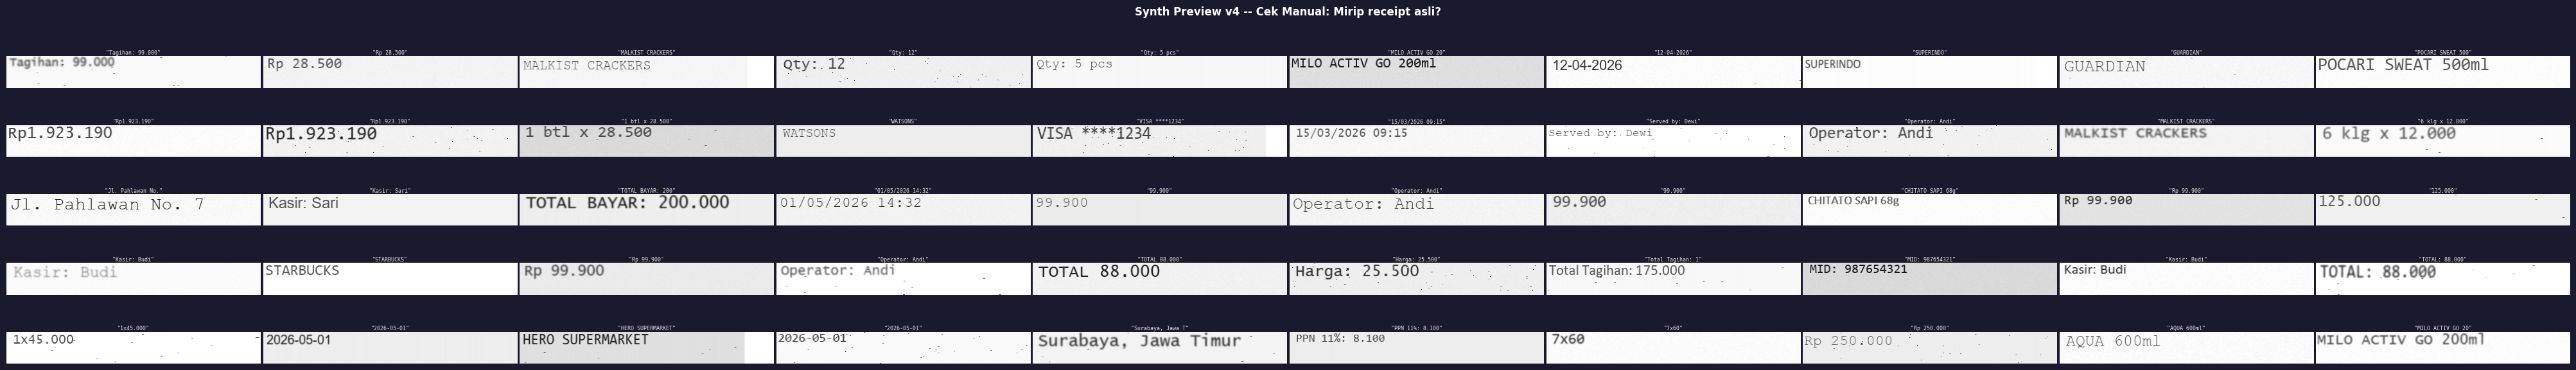

OK Preview disimpan: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_processed\synth_preview_v4.png

CHECKLIST sebelum lanjut ke generation 40K:
  [ ] Hard-case ratio 20-40%?
  [ ] Punct ratio < 25%?
  [ ] Upper & lower ratio seimbang?
  [ ] Visual: tidak semua teks terlalu rapi/AI?
  [ ] TIDAK ada teks completely unreadable?
Kalau semua OK: lanjut ke cell generate 40K


In [6]:
# ── Sanity check distribusi sebelum generate 40K ─────────────────────────────
# Cek: distribusi balanced? punctuation tidak berlebihan? tidak terlalu synthetic?

PREVIEW_N = 200
prev_texts   = []
prev_sources = []
prev_imgs    = []

for _ in range(PREVIEW_N):
    t, src = generate_receipt_line()
    t = t[:MAX_LABEL_LEN]
    prev_texts.append(t)
    prev_sources.append(src)
    prev_imgs.append(create_text_image(t))

# --- Statistik distribusi ---
lengths      = [len(t) for t in prev_texts]
punct_ratio  = [sum(1 for c in t if c in '.,:-/()') / max(len(t), 1) for t in prev_texts]
upper_ratio  = [sum(1 for c in t if c.isupper()) / max(len(t), 1) for t in prev_texts]
lower_ratio  = [sum(1 for c in t if c.islower()) / max(len(t), 1) for t in prev_texts]

from collections import Counter
src_counts = Counter(prev_sources)

print('=' * 55)
print('SANITY CHECK 200 PREVIEW')
print('=' * 55)
print(f'Panjang teks  — Min: {min(lengths)}, Max: {max(lengths)}, Avg: {np.mean(lengths):.1f}')
print(f'Punct ratio   — Avg: {np.mean(punct_ratio):.2%}, Max: {max(punct_ratio):.2%}')
print(f'Upper ratio   — Avg: {np.mean(upper_ratio):.2%}')
print(f'Lower ratio   — Avg: {np.mean(lower_ratio):.2%}')
print()
print('Distribusi kategori:')
for cat, cnt in sorted(src_counts.items(), key=lambda x: -x[1]):
    bar = '#' * cnt
    print(f'  {cat:25s}: {cnt:3d} {bar}')
print()

# Checklist target
hard_cats_set = {"quantity_format", "invoice_format", "lowercase_mixed",
                 "price_format", "alphanumeric_code", "total_format"}
hard_count = sum(v for k, v in src_counts.items() if k in hard_cats_set)
hard_pct   = hard_count / PREVIEW_N

print(f'Hard-case ratio: {hard_pct:.1%}  (target: 25-35%)')
if 0.20 <= hard_pct <= 0.40:
    print('  OK Distribusi hard-case dalam range aman')
else:
    print('  WARNING Distribusi hard-case di luar range — cek generate_receipt_line()')

if np.mean(punct_ratio) > 0.25:
    print('  WARNING Punct ratio terlalu tinggi — risiko model hallucinate punctuation')
else:
    print('  OK Punct ratio normal')

print()
print('20 sampel preview:')
for i, (t, s) in enumerate(zip(prev_texts[:20], prev_sources[:20])):
    print(f'  [{i:02d}] [{s:20s}] "{t}"')

# Visual grid 50 sampel pertama
COLS, ROWS = 10, 5
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 4, ROWS * 1.2))
fig.patch.set_facecolor('#1a1a2e')
for i in range(ROWS * COLS):
    ax = axes[i // COLS, i % COLS]
    ax.imshow(prev_imgs[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'"{prev_texts[i][:16]}"',
                 fontsize=6, color='#e0e0e0', pad=2, fontfamily='monospace')
    ax.axis('off')
plt.suptitle('Synth Preview v4 -- Cek Manual: Mirip receipt asli?',
             fontsize=12, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=0.3)
preview_path = os.path.join(PROJECT_ROOT, 'data', '_processed', 'synth_preview_v4.png')
os.makedirs(os.path.dirname(preview_path), exist_ok=True)
plt.savefig(preview_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'OK Preview disimpan: {preview_path}')
print()
print('CHECKLIST sebelum lanjut ke generation 40K:')
print('  [ ] Hard-case ratio 20-40%?')
print('  [ ] Punct ratio < 25%?')
print('  [ ] Upper & lower ratio seimbang?')
print('  [ ] Visual: tidak semua teks terlalu rapi/AI?')
print('  [ ] TIDAK ada teks completely unreadable?')
print('Kalau semua OK: lanjut ke cell generate 40K')


## 5.4 -- Generate 40K Synthetic Samples + Source Tracking

In [7]:
# ── Target distribusi 40K ─────────────────────────────────────────────────────
# 50% normal receipt  → dari generate_receipt_line() normal cats
# 25% hard-targeted   → dari generate_receipt_line() hard cats
# 15% numeric-heavy   → price_format + total_format + quantity_format
# 10% real crop aug   → dari NB01 (ditambahkan di cell merge bawah)
# Total synth di cell ini: 36.000 (sisanya 4.000 dari real crop)

N_SAMPLES = 36000

images        = []
labels        = []
label_lengths = []
raw_texts     = []
source_log    = []  # source tracking

# Distribusi eksplisit per sample
# 0.00 - 0.555 → normal (generate_receipt_line normal cats)
# 0.555 - 0.833 → hard targeted (generate_receipt_line hard cats)
# 0.833 - 1.00  → numeric-heavy (paksa kategori numeric)
NUMERIC_CATS = ["quantity_format", "price_format", "total_format"]

print(f'Generating {N_SAMPLES} synthetic receipt images (v4)...')
print('Distribusi target: 55% normal | 28% hard | 17% numeric-heavy')

for i in range(N_SAMPLES):
    r = np.random.random()
    
    if r < 0.50:
        # Normal — tapi total & date_time diberi bobot lebih
        normal_cats   = ["merchant_header", "address", "item_name", "price",
                         "total", "date_time", "cashier"]
        normal_weights = [1, 1, 2, 2, 8, 6, 1]  # total=8×, date_time=6×
        available = [(c, w) for c, w in zip(normal_cats, normal_weights)
                     if c in RECEIPT_TEXT_BANK]
        cats_list = [c for c, w in available]
        w_list    = np.array([w for c, w in available], dtype=np.float32)
        w_list    = w_list / w_list.sum()
        cat  = np.random.choice(cats_list, p=w_list)
        text = np.random.choice(RECEIPT_TEXT_BANK[cat])
    elif r < 0.78:
        # Hard targeted
        hard_cats = ["quantity_format", "invoice_format", "lowercase_mixed",
                     "price_format", "alphanumeric_code", "total_format"]
        available = [c for c in hard_cats if c in RECEIPT_TEXT_BANK]
        cat  = np.random.choice(available)
        text = np.random.choice(RECEIPT_TEXT_BANK[cat])
    else:
        # Numeric-heavy
        available = [c for c in NUMERIC_CATS if c in RECEIPT_TEXT_BANK]
        cat  = np.random.choice(available)
        text = np.random.choice(RECEIPT_TEXT_BANK[cat])

    text = text[:MAX_LABEL_LEN]

    # 10% chance: crop sedikit dari kanan (simulasi teks kepotong)
    if np.random.random() < 0.10 and len(text) > 5:
        cut  = np.random.randint(1, min(4, len(text) - 2))
        text = text[:-cut]

    if not label_valid(text) or len(text.strip()) == 0:
        continue

    img           = create_text_image(text, augment=True)
    label, lbl_len = encode_label(text)

    images.append(img)
    labels.append(label)
    label_lengths.append(lbl_len)
    raw_texts.append(text)
    source_log.append({"text": text, "source": cat})

    if (i + 1) % 5000 == 0:
        print(f'  Generated {i + 1}/{N_SAMPLES}')

images        = np.array(images, dtype=np.float32)
images        = np.expand_dims(images, axis=-1)
labels        = np.array(labels, dtype=np.float32)
label_lengths = np.array(label_lengths, dtype=np.float32)

print(f'\nOK Synth images  : {images.shape}')
print(f'   Labels         : {labels.shape}')
print(f'   Source log     : {len(source_log)} entries')

# Simpan source log
log_path = os.path.join(PROJECT_ROOT, 'data', '_processed', 'ocr_source_log.json')
os.makedirs(os.path.dirname(log_path), exist_ok=True)
with open(log_path, 'w') as f:
    json.dump(source_log, f, indent=2, ensure_ascii=False)
print(f'   Source log disimpan: {log_path}')

# Distribusi aktual
from collections import Counter
actual_dist = Counter(s['source'] for s in source_log)
print('\nDistribusi aktual kategori:')
for cat, cnt in sorted(actual_dist.items(), key=lambda x: -x[1]):
    pct = cnt / len(source_log)
    print(f'  {cat:25s}: {cnt:5d} ({pct:.1%})')


Generating 36000 synthetic receipt images (v4)...
Distribusi target: 55% normal | 28% hard | 17% numeric-heavy
  Generated 5000/36000
  Generated 10000/36000
  Generated 15000/36000
  Generated 20000/36000
  Generated 25000/36000
  Generated 30000/36000
  Generated 35000/36000

OK Synth images  : (35796, 50, 400, 1)
   Labels         : (35796, 40)
   Source log     : 35796 entries
   Source log disimpan: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_processed\ocr_source_log.json

Distribusi aktual kategori:
  total                    :  6739 (18.8%)
  date_time                :  5175 (14.5%)
  total_format             :  4407 (12.3%)
  price_format             :  4270 (11.9%)
  quantity_format          :  4252 (11.9%)
  price                    :  1744 (4.9%)
  lowercase_mixed          :  1736 (4.8%)
  invoice_format           :  1722 (4.8%)
  item_name                :  1664 (4.6%)
  alphanumeric_code        :  1487 (4.2%)
  merchant_header          :   891 (2.5%)
  cashi

## 5.5 -- Load Real Data dari NB01 & Merge

In [15]:
import cv2
import pandas as pd

# ── Fungsi preprocessing real crop — HARUS IDENTIK dengan NB08 inference ──
def preprocess_real_crop(img_gray, target_w=IMG_W, target_h=IMG_H):
    """
    Preprocessing real crop untuk training.
    WAJIB identik dengan preprocess_crop_for_ocr() di NB08 inference
    agar tidak ada train-inference gap.

    Pipeline:
      1. CLAHE ringan (clipLimit=1.5)
      2. Denoise ringan (h=5)
      3. Resize LANCZOS4
      4. Linear histogram stretch (P5-P95)
    """
    if img_gray.dtype != np.uint8:
        img_gray = (img_gray * 255).astype(np.uint8)

    # 1. CLAHE ringan
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(4, 4))
    img_gray = clahe.apply(img_gray)

    # 2. Denoise ringan
    img_gray = cv2.fastNlMeansDenoising(img_gray, None, h=5,
                                         templateWindowSize=7,
                                         searchWindowSize=15)

    # 3. Resize LANCZOS4
    img_gray = cv2.resize(img_gray, (target_w, target_h),
                          interpolation=cv2.INTER_LANCZOS4)

    # 4. Linear histogram stretch
    p_low  = float(np.percentile(img_gray,  5))
    p_high = float(np.percentile(img_gray, 95))
    if p_high - p_low > 10:
        arr = (img_gray.astype(np.float32) - p_low) / (p_high - p_low)
        arr = np.clip(arr, 0.0, 1.0)
    else:
        arr = img_gray.astype(np.float32) / 255.0

    return arr


def augment_real_crop(arr_f32):
    """
    Augmentasi ringan pada real crop yang sudah di-preprocess.
    arr_f32: float32 [0,1], shape (IMG_H, IMG_W)
    Mengembalikan arr_f32 yang sedikit dimodifikasi.
    """
    aug = arr_f32.copy()

    # Sedikit brightness shift
    if np.random.random() < 0.5:
        delta = np.random.uniform(-0.08, 0.08)
        aug = np.clip(aug + delta, 0.0, 1.0)

    # Gaussian blur sangat ringan
    if np.random.random() < 0.30:
        sigma = np.random.uniform(0.3, 0.8)
        aug_uint8 = (aug * 255).astype(np.uint8)
        aug_uint8 = cv2.GaussianBlur(aug_uint8, (3, 3), sigma)
        aug = aug_uint8.astype(np.float32) / 255.0

    # Sedikit kontrast shift
    if np.random.random() < 0.30:
        factor = np.random.uniform(0.85, 1.15)
        mean   = aug.mean()
        aug    = np.clip((aug - mean) * factor + mean, 0.0, 1.0)

    # Noise sangat ringan
    if np.random.random() < 0.20:
        noise = np.random.normal(0, 0.015, aug.shape).astype(np.float32)
        aug   = np.clip(aug + noise, 0.0, 1.0)

    return aug


# ── Remap path lintas mesin ───────────────────────────────────────────────────
def remap_image_path(old_path, new_base):
    """
    Ambil hanya filename dari path lama (bisa dari mesin/OS berbeda),
    lalu rebuild path ke folder _ocr_real_crops di PROJECT_ROOT saat ini.
    Robust terhadap perbedaan drive, username, atau separator OS.
    """
    filename = os.path.basename(str(old_path))
    return os.path.join(new_base, 'data', '_ocr_real_crops', filename)


# ── Load real crop dari NB01 via CSV manifest ─────────────────────────────────
real_csv_path = os.path.join(PROJECT_ROOT, 'data', '_csv', 'ocr_real_labels.csv')

real_images  = []
real_labels  = []
real_lengths = []
real_texts   = []

AUGMENT_FACTOR = 4  # setiap real crop diaugment 4x → ~12K real samples

if os.path.exists(real_csv_path):
    df_real = pd.read_csv(real_csv_path)
    print(f'CSV manifest : {len(df_real)} baris')
    print(f'Kolom        : {list(df_real.columns)}')

    # ── Remap path ke lingkungan saat ini ─────────────────────────────────────
    df_real['image_path'] = df_real['image_path'].apply(
        lambda p: remap_image_path(p, PROJECT_ROOT)
    )

    # Verifikasi cepat sebelum loop
    n_exist = df_real['image_path'].apply(os.path.exists).sum()
    print(f'File ditemukan setelah remap: {n_exist:,} / {len(df_real):,}')
    if n_exist == 0:
        print('ERROR: Semua file masih tidak ditemukan setelah remap!')
        print(f'  Contoh path hasil remap : {df_real["image_path"].iloc[0]}')
        print(f'  Pastikan folder _ocr_real_crops ada di dalam PROJECT_ROOT.')
    print()

    skipped_char = 0
    skipped_img  = 0
    loaded_ok    = 0

    for _, row in df_real.iterrows():
        text = str(row['label']).strip()

        if not label_valid(text) or len(text) == 0:
            skipped_char += 1
            continue

        img_path = row['image_path']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            skipped_img += 1
            continue

        # Preprocess utama (identik dengan NB08 inference)
        arr = preprocess_real_crop(img)
        label, lbl_len = encode_label(text)

        # Simpan versi original
        real_images.append(arr)
        real_labels.append(label)
        real_lengths.append(lbl_len)
        real_texts.append(text)
        loaded_ok += 1

        # Augmentasi: AUGMENT_FACTOR-1 versi tambahan
        for _ in range(AUGMENT_FACTOR - 1):
            aug = augment_real_crop(arr)
            real_images.append(aug)
            real_labels.append(label)
            real_lengths.append(lbl_len)
            real_texts.append(text)

    print(f'Real crops loaded : {loaded_ok:,}')
    print(f'Setelah augment   : {loaded_ok * AUGMENT_FACTOR:,} (x{AUGMENT_FACTOR})')
    print(f'Skip char invalid : {skipped_char:,}')
    print(f'Skip img missing  : {skipped_img:,}')

    if len(real_images) > 0:
        real_images  = np.array(real_images,  dtype=np.float32)
        real_images  = np.expand_dims(real_images, axis=-1)
        real_labels  = np.array(real_labels,  dtype=np.float32)
        real_lengths = np.array(real_lengths, dtype=np.float32)
    else:
        print('WARNING: Tidak ada sample real yang valid!')
        real_images  = np.zeros((0, IMG_H, IMG_W, 1), dtype=np.float32)
        real_labels  = np.zeros((0, MAX_LABEL_LEN),   dtype=np.float32)
        real_lengths = np.zeros((0,), dtype=np.float32)
else:
    print(f'WARNING: CSV tidak ditemukan di {real_csv_path}')
    real_images  = np.zeros((0, IMG_H, IMG_W, 1), dtype=np.float32)
    real_labels  = np.zeros((0, MAX_LABEL_LEN),   dtype=np.float32)
    real_lengths = np.zeros((0,), dtype=np.float32)

print(f'Real data shape: {real_images.shape}')

# ── Merge sintetis + real ─────────────────────────────────────────────────────
if len(real_images) > 0:
    images_all  = np.concatenate([images, real_images], axis=0)
    labels_all  = np.concatenate([labels, real_labels], axis=0)
    lengths_all = np.concatenate([label_lengths, real_lengths], axis=0)
    texts_all   = raw_texts + real_texts
else:
    images_all  = images
    labels_all  = labels
    lengths_all = label_lengths
    texts_all   = raw_texts

n_synth = len(images)
n_real  = len(real_images)
n_total = len(images_all)

print(f'\n{"="*50}')
print(f'RINGKASAN DATASET')
print(f'{"="*50}')
print(f'  Sintetis          : {n_synth:,}')
print(f'  Real (x{AUGMENT_FACTOR} augment) : {n_real:,}  ({n_real/n_total*100:.1f}%)')
print(f'  TOTAL             : {n_total:,}')
print(f'{"="*50}')

CSV manifest : 2974 baris
Kolom        : ['image_path', 'label', 'confidence', 'source', 'category']
File ditemukan setelah remap: 2,974 / 2,974

Real crops loaded : 2,974
Setelah augment   : 11,896 (x4)
Skip char invalid : 0
Skip img missing  : 0
Real data shape: (11896, 50, 400, 1)

RINGKASAN DATASET
  Sintetis          : 35,796
  Real (x4 augment) : 11,896  (24.9%)
  TOTAL             : 47,692


## 5.5b — Visualisasi Komposisi Dataset (Sebelum Split)

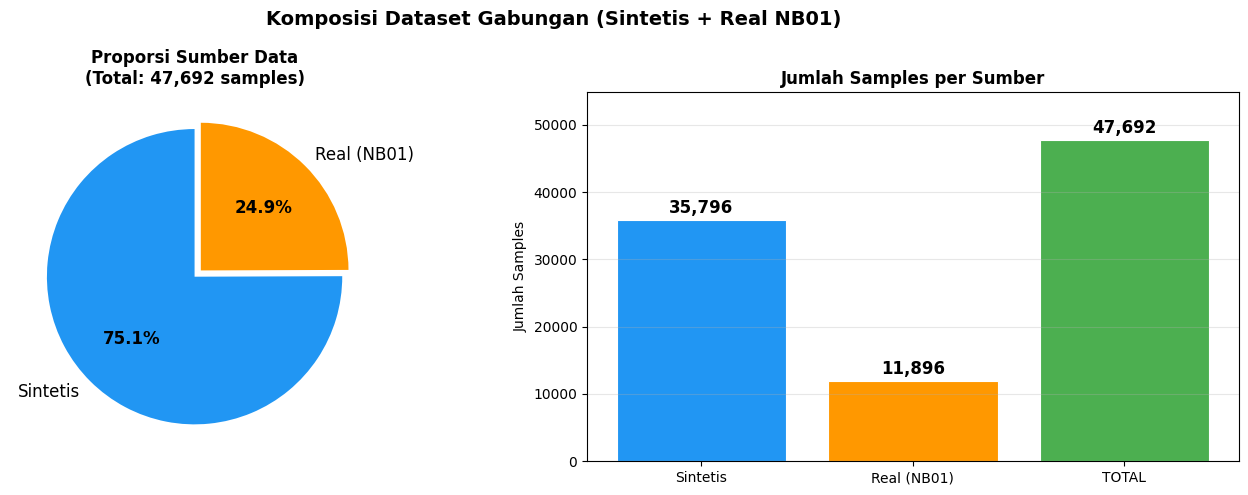

✅ Komposisi dataset tersimpan: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_processed\ocr_dataset_composition_v4.png


In [16]:
# ── Visualisasi 1: Komposisi Dataset ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Komposisi Dataset Gabungan (Sintetis + Real NB01)',
             fontsize=14, fontweight='bold')

# ── Pie chart: proporsi sintetis vs real ──────────────────────────────────────
labels_pie = ['Sintetis', 'Real (NB01)']
sizes_pie  = [n_synth, n_real]
colors_pie = ['#2196F3', '#FF9800']
explode    = (0, 0.06)

if n_real > 0:
    wedges, texts_p, autotexts = axes[0].pie(
        sizes_pie, labels=labels_pie, colors=colors_pie,
        autopct='%1.1f%%', explode=explode, startangle=90,
        textprops={'fontsize': 12})
    for at in autotexts:
        at.set_fontweight('bold')
else:
    axes[0].pie([1], labels=['Sintetis (100%)'], colors=['#2196F3'],
                startangle=90, textprops={'fontsize': 12})
axes[0].set_title(f'Proporsi Sumber Data\n(Total: {n_total:,} samples)',
                  fontsize=12, fontweight='bold')

# ── Bar chart: jumlah absolut ─────────────────────────────────────────────────
bar_labels = ['Sintetis', 'Real (NB01)', 'TOTAL']
bar_vals   = [n_synth, n_real, n_total]
bar_colors = ['#2196F3', '#FF9800', '#4CAF50']

bars = axes[1].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + max(bar_vals)*0.01,
                 f'{val:,}', ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[1].set_title('Jumlah Samples per Sumber', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Samples')
axes[1].set_ylim(0, max(bar_vals) * 1.15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(PROJECT_ROOT, 'data', '_processed',
                          'ocr_dataset_composition_v4.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Komposisi dataset tersimpan: {save_path}')


## 5.5c — Contoh Gambar: Real (NB01) vs Sintetis

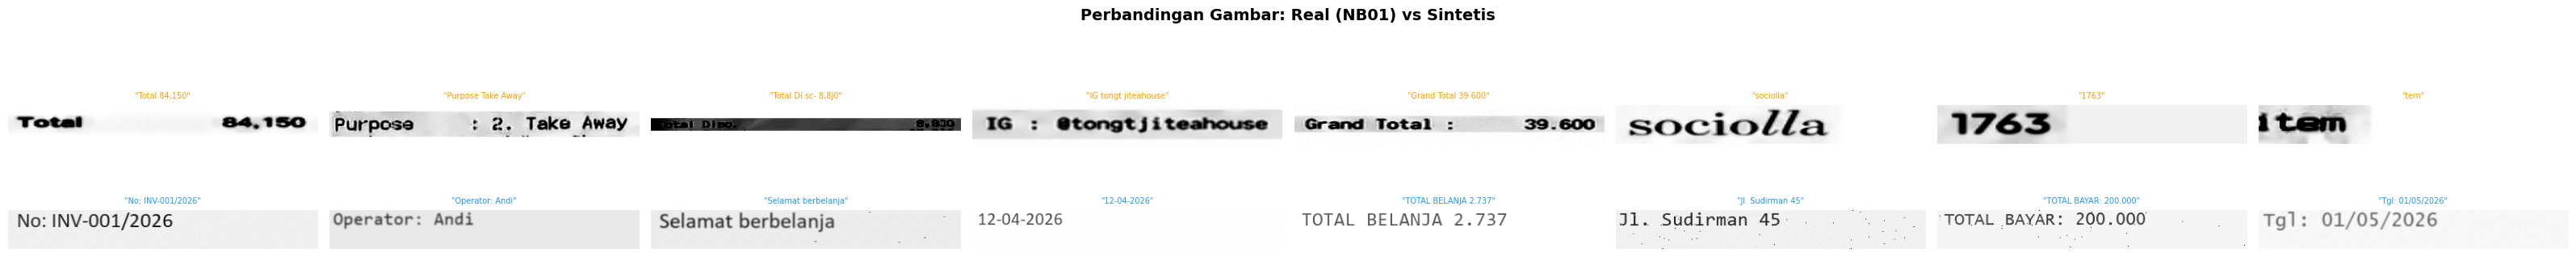

✅ Sample grid Real vs Sintetis tersimpan: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_processed\ocr_sample_real_vs_synth_v4.png


In [17]:
# ── Visualisasi 2: Sample grid Real vs Sintetis ───────────────────────────────
N_SHOW = 8   # jumlah sample per sumber

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 4, 4))
fig.suptitle('Perbandingan Gambar: Real (NB01) vs Sintetis',
             fontsize=14, fontweight='bold')

# ── Baris atas: Real crops dari NB01 ─────────────────────────────────────────
if n_real >= N_SHOW:
    real_sample_idx = np.random.choice(n_real, N_SHOW, replace=False)
    for col, idx in enumerate(real_sample_idx):
        ax = axes[0, col]
        ax.imshow(real_images[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        label_txt = real_texts[idx][:20]
        ax.set_title(f'"{label_txt}"', fontsize=7, color='#FF9800')
        ax.axis('off')
else:
    # Kurang dari N_SHOW — tampilkan semua yang ada
    for col in range(N_SHOW):
        ax = axes[0, col]
        if col < n_real:
            ax.imshow(real_images[col].squeeze(), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'"{real_texts[col][:20]}"', fontsize=7, color='#FF9800')
        else:
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, '(tidak ada)', ha='center', va='center',
                    fontsize=8, color='gray', transform=ax.transAxes)
        ax.axis('off')

# Label baris kiri
axes[0, 0].set_ylabel('🟠 REAL(NB01)', fontsize=10, fontweight='bold',rotation=0, labelpad=60, color='#FF9800')

# ── Baris bawah: Sintetis ─────────────────────────────────────────────────────
synth_sample_idx = np.random.choice(n_synth, N_SHOW, replace=False)
for col, idx in enumerate(synth_sample_idx):
    ax = axes[1, col]
    ax.imshow(images[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    label_txt = raw_texts[idx][:20]
    ax.set_title(f'"{label_txt}"', fontsize=7, color='#2196F3')
    ax.axis('off')

axes[1, 0].set_ylabel('🔵 SINTETIS(NB05)', fontsize=10, fontweight='bold',rotation=0, labelpad=60, color='#2196F3')

plt.tight_layout()
save_path = os.path.join(PROJECT_ROOT, 'data', '_processed',
                          'ocr_sample_real_vs_synth_v4.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sample grid Real vs Sintetis tersimpan: {save_path}')


## 5.6 -- Train/Val/Test Split & Dataset Overview

DISTRIBUSI SETELAH SPLIT (80/10/10)
  Train : (38153, 50, 400, 1)  (38,153)
  Val   : (4769, 50, 400, 1)  (4,769)
  Test  : (4770, 50, 400, 1)  (4,770)
  Total : 47,692


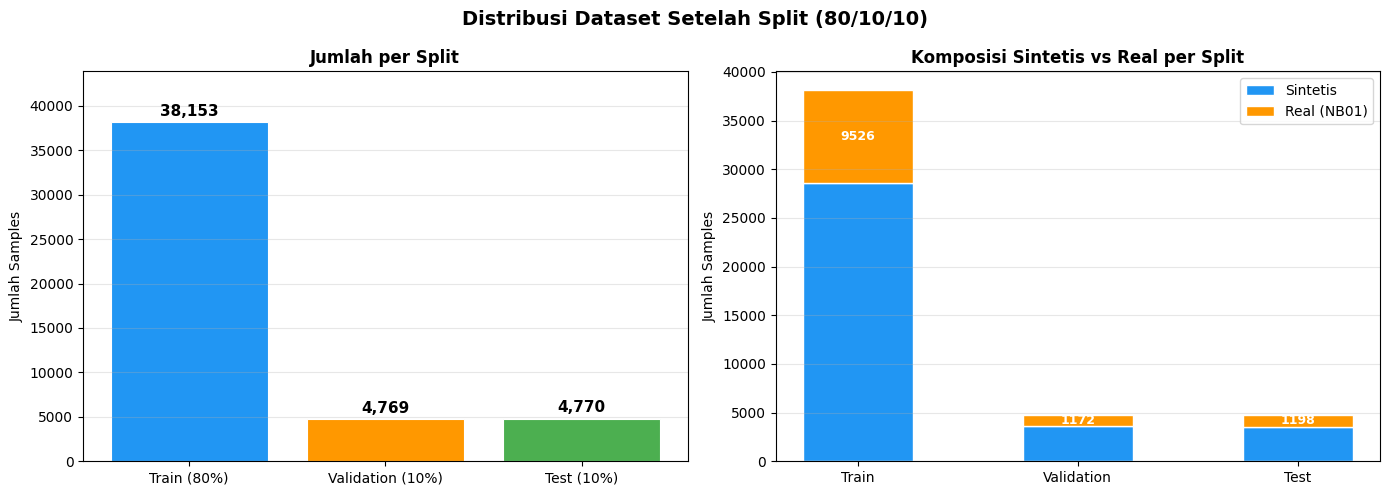


✅ Distribusi split tersimpan: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_processed\ocr_split_distribution_v4.png
OK Dataset split selesai.


In [18]:
from sklearn.model_selection import train_test_split

n_total = len(images_all)
indices = np.arange(n_total)
np.random.shuffle(indices)

# 80% train, 10% val, 10% test
idx_train, idx_temp = train_test_split(indices, test_size=0.20, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_temp,  test_size=0.50, random_state=SEED)

X_train = images_all[idx_train]
X_val   = images_all[idx_val]
X_test  = images_all[idx_test]

y_train = labels_all[idx_train]
y_val   = labels_all[idx_val]
y_test  = labels_all[idx_test]

ll_train = lengths_all[idx_train]
ll_val   = lengths_all[idx_val]
ll_test  = lengths_all[idx_test]

texts_train = [texts_all[i] for i in idx_train]
texts_val   = [texts_all[i] for i in idx_val]
texts_test  = [texts_all[i] for i in idx_test]

n_train = len(X_train)
n_val   = len(X_val)
n_test  = len(X_test)

print(f'{"="*50}')
print(f'DISTRIBUSI SETELAH SPLIT (80/10/10)')
print(f'{"="*50}')
print(f'  Train : {X_train.shape}  ({n_train:,})')
print(f'  Val   : {X_val.shape}  ({n_val:,})')
print(f'  Test  : {X_test.shape}  ({n_test:,})')
print(f'  Total : {n_total:,}')

# ── Visualisasi distribusi setelah split ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Dataset Setelah Split (80/10/10)',
             fontsize=14, fontweight='bold')

# ── Bar chart: jumlah per split ───────────────────────────────────────────────
split_vals   = [n_train, n_val, n_test]
split_labels = ['Train (80%)', 'Validation (10%)', 'Test (10%)']
split_colors = ['#2196F3', '#FF9800', '#4CAF50']

bars = axes[0].bar(split_labels, split_vals, color=split_colors,
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, split_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + max(split_vals)*0.01,
                 f'{val:,}', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)
axes[0].set_title('Jumlah per Split', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Samples')
axes[0].set_ylim(0, max(split_vals) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# ── Stacked bar: proporsi sintetis vs real dalam tiap split ──────────────────
# Hitung jumlah real di masing-masing split berdasarkan index
real_start_idx = n_synth  # real data dimulai dari index n_synth di images_all / texts_all
n_real_train = sum(1 for i in idx_train if i >= real_start_idx)
n_real_val   = sum(1 for i in idx_val   if i >= real_start_idx)
n_real_test  = sum(1 for i in idx_test  if i >= real_start_idx)

n_synth_train = n_train - n_real_train
n_synth_val   = n_val   - n_real_val
n_synth_test  = n_test  - n_real_test

x_pos = np.arange(3)
w = 0.5

bars_synth = axes[1].bar(x_pos, [n_synth_train, n_synth_val, n_synth_test],
                          w, label='Sintetis', color='#2196F3', edgecolor='white')
bars_real  = axes[1].bar(x_pos, [n_real_train, n_real_val, n_real_test],
                          w, bottom=[n_synth_train, n_synth_val, n_synth_test],
                          label='Real (NB01)', color='#FF9800', edgecolor='white')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Train', 'Validation', 'Test'])
axes[1].set_title('Komposisi Sintetis vs Real per Split', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Samples')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

# Label jumlah
for i, (ns, nr) in enumerate(zip([n_synth_train, n_synth_val, n_synth_test],
                                   [n_real_train, n_real_val, n_real_test])):
    if nr > 0:
        axes[1].text(i, ns + nr/2, f'{nr}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
save_path = os.path.join(PROJECT_ROOT, 'data', '_processed',
                          'ocr_split_distribution_v4.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Distribusi split tersimpan: {save_path}')
print('OK Dataset split selesai.')


## 5.7 -- Build OCR Model (CRNN v4: + SpatialDropout2D + recurrent_dropout)

In [19]:
def build_ocr_model(img_h=IMG_H, img_w=IMG_W, num_chars=NUM_CHARS):
    """
    CRNN v5 IMPROVED — A100 Optimized:
    - 4x Conv + BatchNorm + MaxPool (was 3x) ← NEW extra block
    - SpatialDropout2D setelah conv block terakhir
    - 2x BiLSTM WIDER: 256→128 (was 128→64) ← UPGRADED
    - Dense 256 + Dropout
    - Output linear (CTC)
    """
    inputs = tf.keras.Input(shape=(img_h, img_w, 1), name="image")

    # CNN Block 1: 50×400 → 25×200
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 2: 25×200 → 12×100
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 3: 12×100 → 6×100
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)

    # CNN Block 4 (NEW): deepen features tanpa mengurangi spatial
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # SpatialDropout2D — regularisasi fitur spatial
    x = layers.SpatialDropout2D(0.15)(x)

    # Reshape untuk RNN: (batch, 6, 100, 128) → (batch, 100, 768)
    x = layers.Permute((2, 1, 3))(x)
    x = layers.Reshape((-1, x.shape[2] * x.shape[3]))(x)

    x = layers.Dropout(0.25)(x)

    # RNN — WIDER sequence modeling (was 128→64, now 256→128)
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True,
                    dropout=0.2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True,
                    dropout=0.2))(x)

    # Dense intermediate
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.25)(x)

    # Output — float32 eksplisit
    outputs = layers.Dense(num_chars, name='dense_out')(x)
    outputs = layers.Activation('linear', dtype='float32')(outputs)

    model = Model(inputs=inputs, outputs=outputs, name="ocr_model_v5")
    return model


ocr_model = build_ocr_model()
ocr_model.summary()
print(f'Output timesteps: {ocr_model.output_shape[1]}')
print(f'Logit length (timesteps): {ocr_model.output_shape[1]}')

Model: "ocr_model_v5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 50, 400, 1)]      0         
                                                                 
 conv2d_4 (Conv2D)           (None, 50, 400, 32)       320       
                                                                 
 batch_normalization_4 (Batc  (None, 50, 400, 32)      128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 25, 200, 32)      0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 25, 200, 64)       18496     
                                                                 
 batch_normalization_5 (Batc  (None, 25, 200, 64)     

## 5.8 -- Training Loop (v4: + ReduceLROnPlateau + patience=15)

In [20]:
BATCH_SIZE = 64  # A100 optimized (was 32)
MAX_EPOCHS = 150
PATIENCE   = 15
LR_INIT    = 3e-4

# tf.Variable — supaya bisa di-.assign() manual oleh ReduceLROnPlateau
current_lr    = LR_INIT
ocr_optimizer = tf.keras.optimizers.Adam(learning_rate=current_lr, clipnorm=5.0)

# ReduceLROnPlateau state (manual, karena custom training loop)
reduce_lr_patience  = 8
reduce_lr_factor    = 0.5
reduce_lr_min       = 1e-6
reduce_lr_counter   = 0
reduce_lr_best      = float('inf')

# ── TensorBoard Setup ─────────────────────────────────────────────────────────
LOG_DIR = os.path.join(PROJECT_ROOT, 'logs', 'ocr')
os.makedirs(os.path.join(LOG_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(LOG_DIR, 'val'),   exist_ok=True)
train_writer = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'train'))
val_writer   = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'val'))
print(f'TensorBoard logs -> {LOG_DIR}')
print(f'  Jalankan: tensorboard --logdir logs/ocr')

def set_lr(optimizer, new_lr):
    optimizer.learning_rate = new_lr

def compute_ctc_loss(y_true, y_pred, label_length):
    batch_size       = tf.shape(y_pred)[0]
    input_length     = tf.shape(y_pred)[1]
    y_pred_t         = tf.transpose(y_pred, [1, 0, 2])
    y_pred_log       = tf.nn.log_softmax(y_pred_t, axis=-1)
    input_len_tensor = tf.fill([batch_size], tf.cast(input_length, tf.int32))
    label_len_tensor = tf.cast(tf.reshape(label_length, [-1]), tf.int32)
    y_true_int       = tf.cast(y_true, tf.int32)
    loss = tf.nn.ctc_loss(
        labels=y_true_int,
        logits=y_pred_log,
        label_length=label_len_tensor,
        logit_length=input_len_tensor,
        logits_time_major=True,
        blank_index=BLANK_IDX
    )
    return tf.reduce_mean(loss)


tf.config.run_functions_eagerly(False)

@tf.function
def train_step(x_batch, y_batch, ll_batch):
    with tf.GradientTape() as tape:
        preds = ocr_model(x_batch, training=True)
        loss  = compute_ctc_loss(y_batch, preds, ll_batch)
    grads = tape.gradient(loss, ocr_model.trainable_variables)
    gv    = [(g, v) for g, v in zip(grads, ocr_model.trainable_variables) if g is not None]
    if gv:
        ocr_optimizer.apply_gradients(gv)
    return loss


@tf.function
def val_step(x_batch, y_batch, ll_batch):
    preds = ocr_model(x_batch, training=False)
    return compute_ctc_loss(y_batch, preds, ll_batch)


# Setup
ocr_history       = {'train_loss': [], 'val_loss': []}
save_dir          = os.path.join(PROJECT_ROOT, 'models', 'ocr')
os.makedirs(save_dir, exist_ok=True)
best_val_loss     = float('inf')
epochs_no_improve = 0

print('=' * 60)
print(f'OCR TRAINING v5 (CRNN + CTC, {len(images_all)} samples, LR={LR_INIT}, {MAX_EPOCHS} epochs max)')
print(f'Early stop patience: {PATIENCE} | ReduceLR patience: {reduce_lr_patience}')
print('=' * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    # Shuffle train
    perm = np.random.permutation(n_train)
    X_tr_s, y_tr_s, ll_tr_s = X_train[perm], y_train[perm], ll_train[perm]

    # Train
    train_losses = []
    for b in range(0, n_train, BATCH_SIZE):
        xb  = X_tr_s[b:b + BATCH_SIZE]
        yb  = y_tr_s[b:b + BATCH_SIZE]
        llb = ll_tr_s[b:b + BATCH_SIZE]
        if len(xb) == 0:
            continue
        loss = train_step(xb, yb, llb)
        train_losses.append(float(loss))
    t_ctc = np.mean(train_losses)

    # Validation
    val_losses = []
    for b in range(0, len(X_val), BATCH_SIZE):
        xb  = X_val[b:b + BATCH_SIZE]
        yb  = y_val[b:b + BATCH_SIZE]
        llb = ll_val[b:b + BATCH_SIZE]
        if len(xb) == 0:
            continue
        loss = val_step(xb, yb, llb)
        val_losses.append(float(loss))
    v_ctc = np.mean(val_losses)

    ocr_history['train_loss'].append(t_ctc)
    ocr_history['val_loss'].append(v_ctc)

    # ── TensorBoard logging ──────────────────────────────────────────────────
    with train_writer.as_default():
        tf.summary.scalar('Loss/CTC',           t_ctc,       step=epoch)
        tf.summary.scalar('LearningRate',        current_lr,  step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('Loss/CTC',           v_ctc,       step=epoch)
    train_writer.flush()
    val_writer.flush()

    # ReduceLROnPlateau (manual)
    if v_ctc < reduce_lr_best - 1e-4:
        reduce_lr_best    = v_ctc
        reduce_lr_counter = 0
    else:
        reduce_lr_counter += 1
        if reduce_lr_counter >= reduce_lr_patience:
            new_lr = max(current_lr * reduce_lr_factor, reduce_lr_min)
            if new_lr < current_lr:
                current_lr = new_lr
                set_lr(ocr_optimizer, current_lr)  # ← pakai ini, bukan .assign()
                print(f'  ReduceLR -> {current_lr:.2e}')
            reduce_lr_counter = 0
        
    # Checkpoint
    best_tag = ''
    if v_ctc < best_val_loss:
        best_val_loss      = v_ctc
        epochs_no_improve  = 0
        best_tag           = ' << BEST'
        ocr_model.save_weights(os.path.join(save_dir, 'ocr_weights.weights.h5'))
        ocr_model.save(os.path.join(save_dir, 'ocr.keras'))
    else:
        epochs_no_improve += 1

    # Log per epoch
    if epoch <= 20 or epoch % 5 == 0 or best_tag:
        elapsed = time.time() - t0
        print(f'  Epoch {epoch:3d}/{MAX_EPOCHS} | t_ctc={t_ctc:.4f} v_ctc={v_ctc:.4f} | '
              f'lr={current_lr:.1e} | {elapsed:.1f}s{best_tag}')

    # Early stopping
    if epochs_no_improve >= PATIENCE:
        print(f'  Early stop at epoch {epoch}')
        break

print(f'\nBest val CTC loss: {best_val_loss:.4f}')
print(f'TensorBoard logs saved to: {LOG_DIR}')


TensorBoard logs -> c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\logs\ocr
  Jalankan: tensorboard --logdir logs/ocr
OCR TRAINING v5 (CRNN + CTC, 47692 samples, LR=0.0003, 150 epochs max)
Early stop patience: 15 | ReduceLR patience: 8
  Epoch   1/150 | t_ctc=30.2605 v_ctc=11.4961 | lr=3.0e-04 | 98.5s << BEST
  Epoch   2/150 | t_ctc=4.7998 v_ctc=3.0867 | lr=3.0e-04 | 93.8s << BEST
  Epoch   3/150 | t_ctc=2.3951 v_ctc=1.8505 | lr=3.0e-04 | 93.2s << BEST
  Epoch   4/150 | t_ctc=1.7086 v_ctc=1.1220 | lr=3.0e-04 | 97.2s << BEST
  Epoch   5/150 | t_ctc=1.3246 v_ctc=0.9766 | lr=3.0e-04 | 126.4s << BEST
  Epoch   6/150 | t_ctc=1.0801 v_ctc=0.7767 | lr=3.0e-04 | 190.2s << BEST
  Epoch   7/150 | t_ctc=0.9038 v_ctc=0.6544 | lr=3.0e-04 | 138.6s << BEST
  Epoch   8/150 | t_ctc=0.7814 v_ctc=1.2893 | lr=3.0e-04 | 97.9s
  Epoch   9/150 | t_ctc=0.6622 v_ctc=0.5494 | lr=3.0e-04 | 93.9s << BEST
  Epoch  10/150 | t_ctc=0.5648 v_ctc=0.4457 | lr=3.0e-04 | 91.6s << BEST
  Epoch  11/150 | t_ctc=0.4892 

## 5.9 -- Training Curve

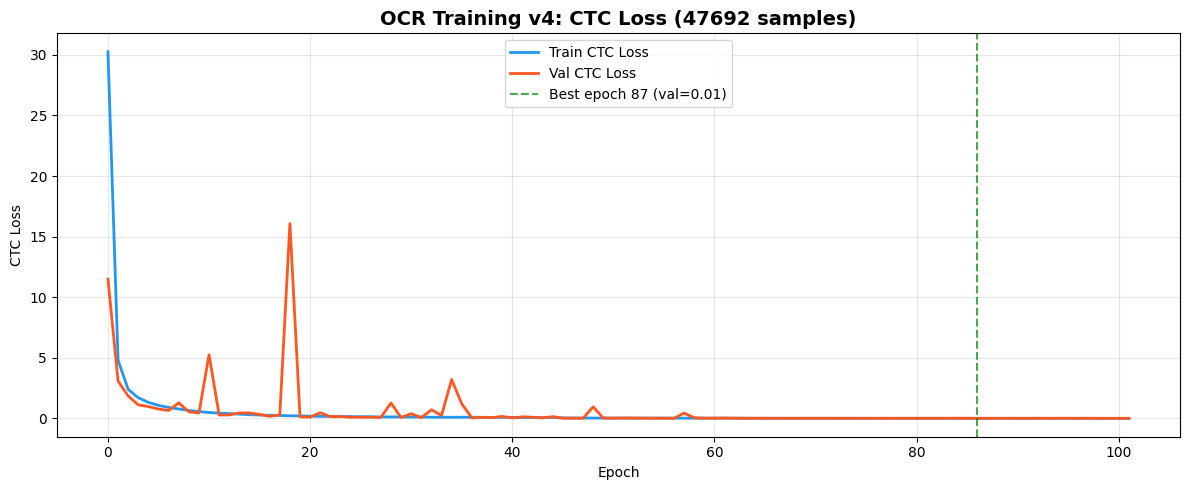

OK OCR training curve saved.


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ocr_history['train_loss'], label='Train CTC Loss', color='#2196F3', linewidth=2)
ax.plot(ocr_history['val_loss'],   label='Val CTC Loss',   color='#FF5722', linewidth=2)
best_ep = int(np.argmin(ocr_history['val_loss']))
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7,
           label=f'Best epoch {best_ep + 1} (val={best_val_loss:.2f})')
ax.set_title(f'OCR Training v4: CTC Loss ({len(images_all)} samples)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('CTC Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed', 'ocr_training_curve_v4.png'), dpi=150)
plt.show()
print('OK OCR training curve saved.')


## 5.10 -- Float32 Fix + Weight Verification + Re-save

In [22]:
import numpy as np
import os
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('float32')
print(f'[1/5] Policy: {mixed_precision.global_policy().name}  (target: float32)')

ocr_model_f32 = build_ocr_model()
print('[2/5] Model float32 dibangun ulang.')

weights_path = os.path.join(save_dir, 'ocr_weights.h5')
keras_path   = os.path.join(save_dir, 'ocr.keras')

loaded_ok = False
if os.path.exists(keras_path):
    try:
        ocr_model_f32 = tf.keras.models.load_model(
            keras_path,
            custom_objects={'CTCLayer': CTCLayer},
            compile=False
        )
        loaded_ok = True
        print('[3/5] OK Loaded dari ocr.keras')
    except Exception as e:
        print(f'[3/5] WARNING ocr.keras gagal: {e} — coba ocr_weights.h5')

if not loaded_ok and os.path.exists(weights_path):
    try:
        _ = ocr_model_f32(tf.zeros((1, IMG_H, IMG_W, 1)))
        ocr_model_f32.load_weights(weights_path)
        loaded_ok = True
        print('[3/5] OK Loaded dari ocr_weights.h5')
    except Exception as e:
        print(f'[3/5] ERROR Kedua format gagal: {e}')

if not loaded_ok:
    print('[3/5] WARNING Tidak ada file — fallback ke training weights di memori')
    ocr_model_f32.set_weights([
        w.astype('float32') if hasattr(w, 'astype') else w
        for w in ocr_model.get_weights()
    ])
    print('[3/5] OK Weights disalin dari training model')

# Verifikasi
print('[4/5] Verifikasi weights...')
all_weights = ocr_model_f32.get_weights()
for i, w in enumerate(all_weights):
    w_f32 = w.astype('float32')
    issue = None
    if np.all(w_f32 == 0):
        issue = f'Layer {i}: semua ZERO'
    elif np.any(np.isnan(w_f32)):
        issue = f'Layer {i}: ada NaN'
    elif np.any(np.isinf(w_f32)):
        issue = f'Layer {i}: ada Inf'
    if issue:
        print(f'  WARNING {issue} — auto-fix dari training weights')
        src = ocr_model.get_weights()
        if i < len(src):
            all_weights[i] = src[i].astype('float32')

ocr_model_f32.set_weights([w.astype('float32') for w in all_weights])

test_out = ocr_model_f32(tf.zeros((1, IMG_H, IMG_W, 1)), training=False)
print(f'  Output dtype: {test_out.dtype}, shape: {test_out.shape}')
if tf.reduce_any(tf.math.is_nan(test_out)):
    print('  ERROR Output mengandung NaN')
else:
    print('  OK Output bersih (tidak ada NaN)')

# Quick CER check 10 sampel
print('\n  Quick CER check (10 sampel):')
sample_preds = ocr_model_f32.predict(X_test[:10], verbose=0)
cer_samples  = []
for i in range(10):
    logit = np.expand_dims(sample_preds[i], axis=0)
    pred  = decode_prediction(logit)
    true  = texts_test[i]
    dist  = editdistance.eval(true, pred)
    c     = dist / max(len(true), 1)
    cer_samples.append(c)
    print(f"  [{i}] True: '{true[:20]:20s}' | Pred: '{pred[:20]:20s}' | CER: {c:.2%}")
print(f'  Avg Quick CER: {np.mean(cer_samples):.2%}')

# Re-save
print('\n[5/5] Re-saving semua format (float32)...')
ocr_model_f32.save_weights(os.path.join(save_dir, 'ocr_weights_fixed.h5'))
ocr_model_f32.save(os.path.join(save_dir, 'ocr_fixed.keras'))
tf.saved_model.save(ocr_model_f32, os.path.join(save_dir, 'ocr_saved_fixed'))
print(f'  OK ocr_weights_fixed.h5 → {save_dir}')
print(f'  OK ocr_fixed.keras      → {save_dir}')
print(f'  OK ocr_saved_fixed/     → {save_dir}')

ocr_model = ocr_model_f32
print('\nOK Cell 5.10 selesai. ocr_model = float32, weights bersih.')


[1/5] Policy: float32  (target: float32)
[2/5] Model float32 dibangun ulang.
[3/5] OK Loaded dari ocr.keras
[4/5] Verifikasi weights...
  Output dtype: <dtype: 'float32'>, shape: (1, 100, 73)
  OK Output bersih (tidak ada NaN)

  Quick CER check (10 sampel):
  [0] True: 'TUNAI 540 000       ' | Pred: 'TUNAI 540 000       ' | CER: 0.00%
  [1] True: 'foko Tokopedia      ' | Pred: 'foko Tokopedia      ' | CER: 0.00%
  [2] True: 'Tagihan: 99.000     ' | Pred: 'Tagihan: 99.000     ' | CER: 0.00%
  [3] True: 'Rp 500              ' | Pred: 'Rp 500              ' | CER: 0.00%
  [4] True: 'Rp 4.800            ' | Pred: 'Rp 4.800            ' | CER: 0.00%
  [5] True: 'TELP 02186909112    ' | Pred: 'TELP 02186909112    ' | CER: 0.00%
  [6] True: 'PASTA GIGI PEPSODENT' | Pred: 'PASTA GIGI PEPSODENT' | CER: 0.00%
  [7] True: '10x25               ' | Pred: '10x25               ' | CER: 0.00%
  [8] True: 'LAYANAN KONSUMEN    ' | Pred: 'LAYANAN KONSUMEN    ' | CER: 0.00%
  [9] True: '1x45.000         

INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\ocr\ocr_saved_fixed\assets


INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\ocr\ocr_saved_fixed\assets


  OK ocr_weights_fixed.h5 → c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\ocr
  OK ocr_fixed.keras      → c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\ocr
  OK ocr_saved_fixed/     → c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\ocr

OK Cell 5.10 selesai. ocr_model = float32, weights bersih.


## 5.11 -- Evaluasi Full Test Set (CER/WER)

In [23]:
print('\nComputing CER and WER on full test set...')
all_true_texts = texts_test
all_pred_texts = []

test_preds = ocr_model.predict(X_test, verbose=1)
for i in range(len(X_test)):
    logit  = np.expand_dims(test_preds[i], axis=0)
    decoded = decode_prediction(logit)
    all_pred_texts.append(decoded)

cer = character_error_rate(all_true_texts, all_pred_texts)
wer = word_error_rate(all_true_texts, all_pred_texts)

print(f'\n{"=" * 50}')
print('OCR TEST METRICS (v4)')
print(f'{"=" * 50}')
print(f'  Character Error Rate (CER): {cer:.4f} ({cer*100:.2f}%)')
print(f'  Word Error Rate (WER):      {wer:.4f} ({wer*100:.2f}%)')
print(f'  Best Val CTC Loss:          {best_val_loss:.4f}')
print(f'{"=" * 50}')

# CER per kategori source
print('\nCER per source kategori:')
# Load source log
if os.path.exists(log_path):
    with open(log_path) as f:
        src_log = json.load(f)
    src_map = {s['text']: s['source'] for s in src_log}

    cat_errors = {}
    for true_t, pred_t in zip(all_true_texts, all_pred_texts):
        cat = src_map.get(true_t, 'unknown')
        if cat not in cat_errors:
            cat_errors[cat] = {'dist': 0, 'len': 0, 'n': 0}
        cat_errors[cat]['dist'] += editdistance.eval(true_t, pred_t)
        cat_errors[cat]['len']  += max(len(true_t), 1)
        cat_errors[cat]['n']    += 1

    for cat, v in sorted(cat_errors.items(), key=lambda x: -x[1]['dist']/x[1]['len']):
        cat_cer = v['dist'] / v['len']
        print(f'  {cat:25s}: CER={cat_cer:.2%}  (n={v["n"]})')
else:
    print('  (source log tidak tersedia)')



Computing CER and WER on full test set...
150/150 [==============================] - 2s 14ms/step

OCR TEST METRICS (v4)
  Character Error Rate (CER): 0.0003 (0.03%)
  Word Error Rate (WER):      0.0012 (0.12%)
  Best Val CTC Loss:          0.0098

CER per source kategori:
  quantity_format          : CER=0.10%  (n=444)
  unknown                  : CER=0.07%  (n=1187)
  alphanumeric_code        : CER=0.05%  (n=153)
  lowercase_mixed          : CER=0.04%  (n=166)
  total_format             : CER=0.00%  (n=459)
  price_format             : CER=0.00%  (n=457)
  item_name                : CER=0.00%  (n=176)
  date_time                : CER=0.00%  (n=520)
  total                    : CER=0.00%  (n=605)
  invoice_format           : CER=0.00%  (n=154)
  merchant_header          : CER=0.00%  (n=120)
  price                    : CER=0.00%  (n=148)
  cashier                  : CER=0.00%  (n=89)
  address                  : CER=0.00%  (n=92)


## 5.12 -- Inference Demo

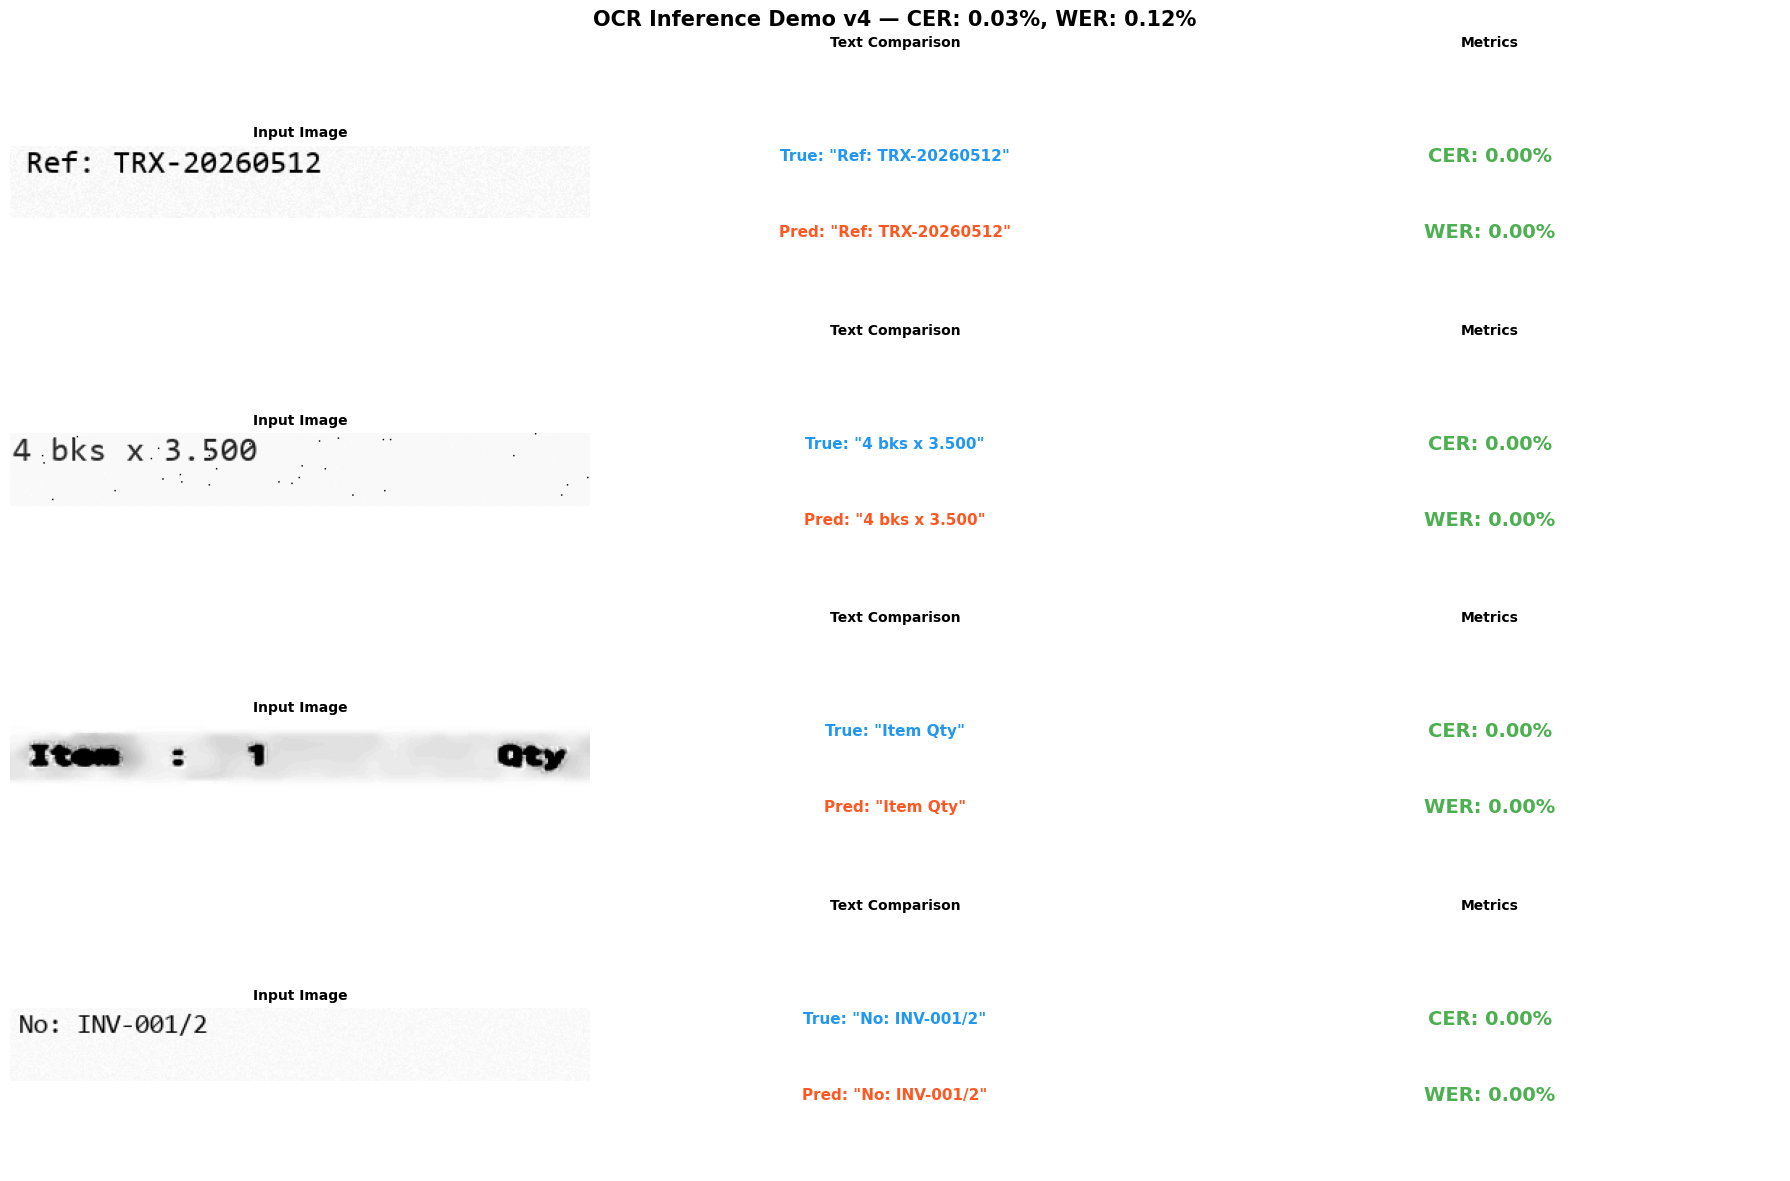

OK OCR inference demo saved.


In [24]:
# Inference demo: 4 random sampel dari test set
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
demo_indices = np.random.choice(len(X_test), 4, replace=False)

for row, idx_val in enumerate(demo_indices):
    img       = X_test[idx_val]
    true_text = all_true_texts[idx_val]
    pred_text = all_pred_texts[idx_val]
    sample_cer = editdistance.eval(true_text, pred_text) / max(len(true_text), 1)
    sample_wer = editdistance.eval(true_text.split(), pred_text.split()) / max(len(true_text.split()), 1)

    axes[row, 0].imshow(img.squeeze(), cmap='gray')
    axes[row, 0].set_title('Input Image', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].text(0.5, 0.6, f'True: "{true_text}"',
                      ha='center', va='center', fontsize=11,
                      fontweight='bold', color='#2196F3',
                      transform=axes[row, 1].transAxes)
    axes[row, 1].text(0.5, 0.3, f'Pred: "{pred_text}"',
                      ha='center', va='center', fontsize=11,
                      fontweight='bold', color='#FF5722',
                      transform=axes[row, 1].transAxes)
    axes[row, 1].set_title('Text Comparison', fontsize=10, fontweight='bold')
    axes[row, 1].axis('off')

    color = '#4CAF50' if sample_cer < 0.3 else '#FF9800' if sample_cer < 0.6 else '#FF5722'
    axes[row, 2].text(0.5, 0.6, f'CER: {sample_cer:.2%}',
                      ha='center', va='center', fontsize=14,
                      fontweight='bold', color=color,
                      transform=axes[row, 2].transAxes)
    axes[row, 2].text(0.5, 0.3, f'WER: {sample_wer:.2%}',
                      ha='center', va='center', fontsize=14,
                      fontweight='bold', color=color,
                      transform=axes[row, 2].transAxes)
    axes[row, 2].set_title('Metrics', fontsize=10, fontweight='bold')
    axes[row, 2].axis('off')

plt.suptitle(f'OCR Inference Demo v4 — CER: {cer:.2%}, WER: {wer:.2%}',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed',
                         'ocr_inference_demo_v4.png'), dpi=150)
plt.show()
print('OK OCR inference demo saved.')


## 5.13 -- Mini Inference Test (kata-kata spesifik)

In [25]:
# Test decode pipeline dengan kata-kata yang diketahui
test_words = [
    "HELLO", "TOTAL", "INDOMARET", "BCA QRIS", "Rp105.800",
    "Kembali: 70.780", "Invoice: INV-2026050", "6x61", "PPN 810",
    "TOTAL BELANJA 2.737",
]

print('Mini Inference Test:')
print(f'{"GT":30s} | {"PR":30s} | CER')
print('-' * 70)
for word in test_words:
    img       = create_text_image(word, augment=False)  # no augment untuk clean test
    img_input = np.expand_dims(np.expand_dims(img, axis=0), axis=-1)
    logit     = ocr_model.predict(img_input, verbose=0)
    pred      = decode_prediction(logit)
    cer_val   = editdistance.eval(word, pred) / max(len(word), 1)
    status    = 'OK' if cer_val < 0.3 else 'WARN' if cer_val < 0.6 else 'FAIL'
    print(f'{word:30s} | {pred:30s} | {cer_val:.2%} [{status}]')


Mini Inference Test:
GT                             | PR                             | CER
----------------------------------------------------------------------
HELLO                          | HELLO                          | 0.00% [OK]
TOTAL                          | TOTAL                          | 20.00% [OK]
INDOMARET                      | INDOMARET                      | 0.00% [OK]
BCA QRIS                       | BCA QRIS                       | 0.00% [OK]
Rp105.800                      | Rp105.800                      | 0.00% [OK]
Kembali: 70.780                | Kembali: 70.780                | 0.00% [OK]
Invoice: INV-2026050           | Invoice: INV-2026050           | 0.00% [OK]
6x61                           | 6x61                           | 0.00% [OK]
PPN 810                        | PPN 810                        | 0.00% [OK]
TOTAL BELANJA 2.737            | TOTAL BELANJA 2.737            | 0.00% [OK]


## 5.14 -- Laporan Akhir

In [26]:
print(f"""
=====================================================
LAPORAN: Notebook 05 -- Training OCR v4
=====================================================

KONFIGURASI:
- MAX_LABEL_LEN : {MAX_LABEL_LEN} karakter
- CHARS         : {len(CHARS)} karakter
- IMG_W x IMG_H : {IMG_W} x {IMG_H} px
- N sintetis    : {len(images)}
- N real (nb01) : {len(real_images)}
- N total       : {len(images_all)}
- Precision     : float32
- Early stop    : patience={PATIENCE}
- ReduceLR      : patience={reduce_lr_patience}, factor={reduce_lr_factor}

ARSITEKTUR:
- 3x Conv + BatchNorm + MaxPool
- SpatialDropout2D(0.1)
- 2x BiLSTM (dropout=0.2, recurrent_dropout=0.1)
- Dense 256 + Dropout(0.25)
- CTC Loss (blank_index={BLANK_IDX})

DATASET:
- Distribusi: 55% normal | 28% hard-targeted | 17% numeric-heavy
- Hard-case patterns: quantity, invoice, lowercase, price, payment, total
- Source tracking: {log_path}

HASIL:
- Best Val CTC  : {best_val_loss:.4f}
- Test CER      : {cer:.4f} ({cer*100:.2f}%)
- Test WER      : {wer:.4f} ({wer*100:.2f}%)

OUTPUT FILES:
- models/ocr/ocr_weights_fixed.h5   <- GUNAKAN INI di nb06
- models/ocr/ocr_fixed.keras        <- GUNAKAN INI di nb06
- models/ocr/ocr_saved_fixed/       (SavedModel)
- data/_processed/ocr_source_log.json
- data/_processed/synth_preview_v4.png
- data/_processed/ocr_dataset_overview_v4.png
- data/_processed/ocr_training_curve_v4.png
- data/_processed/ocr_inference_demo_v4.png
=====================================================
""")



LAPORAN: Notebook 05 -- Training OCR v4

KONFIGURASI:
- MAX_LABEL_LEN : 40 karakter
- CHARS         : 71 karakter
- IMG_W x IMG_H : 400 x 50 px
- N sintetis    : 35796
- N real (nb01) : 11896
- N total       : 47692
- Precision     : float32
- Early stop    : patience=15
- ReduceLR      : patience=8, factor=0.5

ARSITEKTUR:
- 3x Conv + BatchNorm + MaxPool
- SpatialDropout2D(0.1)
- 2x BiLSTM (dropout=0.2, recurrent_dropout=0.1)
- Dense 256 + Dropout(0.25)
- CTC Loss (blank_index=72)

DATASET:
- Distribusi: 55% normal | 28% hard-targeted | 17% numeric-heavy
- Hard-case patterns: quantity, invoice, lowercase, price, payment, total
- Source tracking: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_processed\ocr_source_log.json

HASIL:
- Best Val CTC  : 0.0098
- Test CER      : 0.0003 (0.03%)
- Test WER      : 0.0012 (0.12%)

OUTPUT FILES:
- models/ocr/ocr_weights_fixed.h5   <- GUNAKAN INI di nb06
- models/ocr/ocr_fixed.keras        <- GUNAKAN INI di nb06
- models/ocr/ocr_saved_